In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("C:/Users/samik/Downloads/customer_churn.csv")
df.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1


In [3]:
# drop column Names, Location and Company
# removing the columns that are not needed for the model building
# only numerical data is needed for the model building

df.drop(['Names','Location','Company', 'Onboard_date'],axis=1,inplace=True)

In [4]:
# datatypes of columns
df.dtypes

Age                float64
Total_Purchase     float64
Account_Manager      int64
Years              float64
Num_Sites          float64
Churn                int64
dtype: object

In [5]:
# sigmoid function
def sigmoid(z):
    return 1/(1+np.exp(-z))


In [6]:
# cost function
def costFunction(X, y, theta):
    m = len(y)
    h = sigmoid(X.dot(theta))
    error = (y*np.log(h) + (1-y)*np.log(1-h))
    cost = -1/m * sum(error)
    grad = 1/m * X.T.dot(h-y)
    return cost, grad


In [7]:
# gradient descent
def gradientDescent(X, y, theta, alpha, iterations):
    cost_history = np.zeros(iterations)
    for i in range(iterations):
        cost, grad = costFunction(X, y, theta)
        theta -= alpha * grad
        cost_history[i] = cost
    return theta, cost_history


In [8]:
# predict function
def predict(X, theta):
    return sigmoid(X.dot(theta))

In [9]:
# accuracy function
def accuracy(y_true, y_pred):
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    return accuracy

In [10]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Churn', axis=1), df['Churn'], test_size=0.2, random_state=42)

In [11]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
# add intercept
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]


In [13]:
# train model
theta, cost_history = gradientDescent(X_train, y_train, np.zeros(X_train.shape[1]), alpha=0.01, iterations=1000)


Text(0.5, 1.0, 'Cost history')

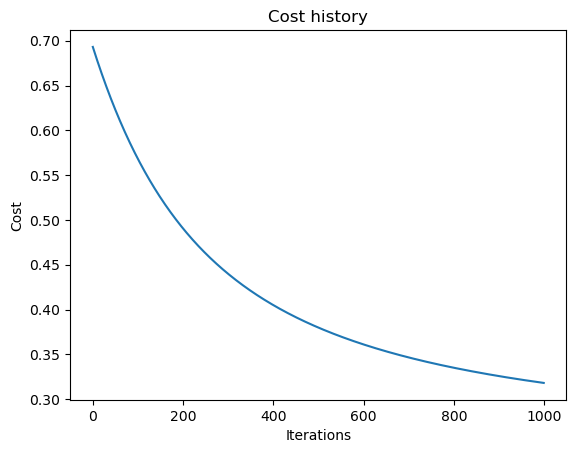

In [14]:
# plot cost history
plt.plot(range(1000), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost history')


In [15]:
# predict
y_pred = predict(X_test, theta)
y_pred = [1 if i > 0.5 else 0 for i in y_pred]


In [16]:
# accuracy
accuracy(y_test, y_pred)*100

np.float64(88.88888888888889)

In [18]:
df2 = pd.read_csv("C:/Users/samik/Downloads/new_customers_1.csv")
df2.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company
0,Andrew Mccall,37.0,9935.53,1,7.71,8.0,2011-08-29 18:37:54,38612 Johnny Stravenue Nataliebury WI 15717-8316,King Ltd
1,Michele Wright,23.0,7526.94,1,9.28,15.0,2013-07-22 18:19:54,"21083 Nicole Junction Suite 332, Youngport ME ...",Cannon-Benson


In [19]:
df2.drop(['Names','Location','Company', 'Onboard_date'],axis=1,inplace=True)

In [20]:
df2

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
0,37.0,9935.53,1,7.71,8.0
1,23.0,7526.94,1,9.28,15.0
2,65.0,100.00,1,1.00,15.0
3,32.0,6487.50,0,9.40,14.0
4,32.0,13147.71,1,10.00,8.0
5,22.0,8445.26,1,3.46,14.0


In [21]:
# apply prediction on new data
X_new = scaler.transform(df2)
X_new = np.c_[np.ones((X_new.shape[0], 1)), X_new]
y_pred_new = predict(X_new, theta)
y_pred_new = [1 if i > 0.5 else 0 for i in y_pred_new]
y_pred_new

# insert prediction into dataframe
df2['Churn'] = y_pred_new
df2

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,37.0,9935.53,1,7.71,8.0,0
1,23.0,7526.94,1,9.28,15.0,1
2,65.0,100.00,1,1.00,15.0,1
3,32.0,6487.50,0,9.40,14.0,1
4,32.0,13147.71,1,10.00,8.0,0
5,22.0,8445.26,1,3.46,14.0,1
